In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
# ==========================================================
# 1. DATA PREPARATION & FEATURE GROUPING
# ==========================================================
# Load merged DataFrame (FreeSurfer stats + clinical data)
df = pd.read_csv('structural_full_68_68_16_edited.csv')

# Group 1: Morphometric Features (subject to residualization)
morph_features = [
    'lh_rostralmiddlefrontal_thick', 'rh_rostralmiddlefrontal_thick',
    'lh_Caudate_vol', 'rh_Caudate_vol',
    'lh_Putamen_vol', 'rh_Putamen_vol',
    'lh_Accumbens_vol', 'rh_Accumbens_vol',
    'lh_lateralorbitofrontal_thick', 'lh_rostralanteriorcingulate_thick'
]

# Group 2: Biological & Technical Confounders (to regress out)
nuisance_covariates = ['age', 'sex', 'eTIV']

# Group 3: Clinical / Experimental Predictors (kept intact)
clinical_predictors = ['vas_t0', 'treatment_group']

# Target Variable
target = 'vas_t1'

# Extract arrays
X_morph = df[morph_features].values
X_nuisance = df[nuisance_covariates].values
X_clinical = df[clinical_predictors].values
y = df[target].values

In [21]:
y.shape

(45,)

In [22]:
# ==========================================================
# 2. CROSS-VALIDATION PIPELINE WITH RESIDUALIZATION
# ==========================================================
loo = LeaveOneOut()

y_true = []
y_pred = []
feature_weights = []

print("Starting Leave-One-Out Cross-Validation Pipeline...\n")

for fold_idx, (train_idx, test_idx) in enumerate(loo.split(X_morph)):
    # --- A. Split into Train / Test Folds ---
    X_m_train, X_m_test = X_morph[train_idx], X_morph[test_idx]
    X_n_train, X_n_test = X_nuisance[train_idx], X_nuisance[test_idx]
    X_c_train, X_c_test = X_clinical[train_idx], X_clinical[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # --- B. Step 1: Nuisance Covariate Residualization ---
    # Fit linear regressor on training morphometry using training nuisance metrics
    nuisance_regressor = LinearRegression()
    nuisance_regressor.fit(X_n_train, X_m_train)
    
    # Calculate residuals: Morphometry_clean = Morphometry_raw - Predicted_by_Confounders
    X_m_train_clean = X_m_train - nuisance_regressor.predict(X_n_train)
    X_m_test_clean = X_m_test - nuisance_regressor.predict(X_n_test)
    
    # --- C. Step 2: Assemble Final Feature Set ---
    # Stack cleaned morphometry with clinical predictors
    X_train_final = np.hstack([X_m_train_clean, X_c_train])
    X_test_final = np.hstack([X_m_test_clean, X_c_test])
    
    # --- D. Step 3: Feature Scaling ---
    # Z-score features strictly based on training distribution
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_final)
    X_test_scaled = scaler.transform(X_test_final)
    
    # --- E. Step 4: Hyperparameter Tuning via Inner CV ---
    param_grid = {
        'alpha': [0.01, 0.1, 1.0, 5.0, 10.0],
        'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9] # L1 (Lasso) vs L2 (Ridge) balance
    }
    
    base_model = ElasticNet(max_iter=10000, random_state=42)
    inner_cv = GridSearchCV(
        base_model, 
        param_grid, 
        cv=3, 
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    inner_cv.fit(X_train_scaled, y_train)
    
    # --- F. Step 5: Fit Best Model & Predict ---
    best_model = inner_cv.best_estimator_
    best_model.fit(X_train_scaled, y_train)
    
    pred = best_model.predict(X_test_scaled)
    
    y_true.append(y_test[0])
    y_pred.append(pred[0])
    feature_weights.append(best_model.coef_)


Starting Leave-One-Out Cross-Validation Pipeline...



In [25]:
feature_weights

[array([-0.61557452, -0.20203232,  0.16713155,  0.        ,  0.40789687,
        -0.05000035, -0.        , -0.37268787,  0.        ,  0.27254076,
         1.16456459, -0.4547537 ]),
 array([-0.41540519, -0.5405684 ,  0.        ,  0.        ,  0.45863178,
         0.        , -0.17413041, -0.02920179,  0.16501797,  0.36024746,
         1.20576443, -0.51965439]),
 array([-0.47214212, -0.45347362,  0.        ,  0.02235339,  0.45754428,
         0.        , -0.17211031, -0.06332561,  0.22095973,  0.27251985,
         1.21475831, -0.5506735 ]),
 array([-0.42732724, -0.50003404,  0.        ,  0.        ,  0.45801682,
         0.        , -0.1331262 , -0.10188904,  0.19837894,  0.32039494,
         1.21257348, -0.54629424]),
 array([-0.46669808, -0.46539823,  0.        ,  0.        ,  0.44687531,
         0.        , -0.14485826, -0.11046154,  0.25174404,  0.28473085,
         1.20776973, -0.5473305 ]),
 array([-0.5096705 , -0.34515608,  0.        ,  0.        ,  0.37140121,
         0.      

In [26]:

# ==========================================================
# 3. EVALUATION & FEATURE IMPORTANCE REPORT
# ==========================================================
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Performance Metrics
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)
corr = np.corrcoef(y_true, y_pred)[0, 1]

print("================ MODEL EVALUATION ================")
print(f"Mean Squared Error (MSE)   : {mse:.4f}")
print(f"Root Mean Squared Error    : {rmse:.4f}")
print(f"R-squared (R^2) Score      : {r2:.4f}")
print(f"Pearson Correlation (r)    : {corr:.4f}")
print("==================================================")

# Average Feature Weights Across Folds
all_feature_names = morph_features + clinical_predictors
avg_weights = np.mean(feature_weights, axis=0)

weights_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Avg_Weight': avg_weights,
    'Abs_Weight': np.abs(avg_weights)
}).sort_values(by='Abs_Weight', ascending=False)

print("\n--- Top Predictive Features Across LOO Folds ---")
print(weights_df[['Feature', 'Avg_Weight']].to_string(index=False))

================ MODEL EVALUATION ================
Mean Squared Error (MSE)   : 5.4038
Root Mean Squared Error    : 2.3246
R-squared (R^2) Score      : 0.0476
Pearson Correlation (r)    : 0.2896

--- Top Predictive Features Across LOO Folds ---
                          Feature  Avg_Weight
                           vas_t0    1.014739
                  treatment_group   -0.454390
    rh_rostralmiddlefrontal_thick   -0.409186
    lh_rostralmiddlefrontal_thick   -0.360028
                   lh_Putamen_vol    0.348696
lh_rostralanteriorcingulate_thick    0.244979
    lh_lateralorbitofrontal_thick    0.139594
                 lh_Accumbens_vol   -0.128718
                 rh_Accumbens_vol   -0.084849
                   rh_Putamen_vol    0.011226
                   rh_Caudate_vol    0.006025
                   lh_Caudate_vol    0.004409


In [ ]:
# ==========================================================
# 4. SUBGROUP EVALUATION: ACTIVE VS. SHAM
# ==========================================================
# Extract treatment array (2 = Active, 1 = Sham)
treatment_vec = df['treatment_group'].values

# Create boolean masks
active_mask = (treatment_vec == 2) 
sham_mask = (treatment_vec == 1)

# --- Active Group Metrics ---
y_true_active = y_true[active_mask]
y_pred_active = y_pred[active_mask]

mse_active = mean_squared_error(y_true_active, y_pred_active)
rmse_active = np.sqrt(mse_active)
r2_active = r2_score(y_true_active, y_pred_active)
corr_active = np.corrcoef(y_true_active, y_pred_active)[0, 1]

# --- Sham Group Metrics ---
y_true_sham = y_true[sham_mask]
y_pred_sham = y_pred[sham_mask]

mse_sham = mean_squared_error(y_true_sham, y_pred_sham)
rmse_sham = np.sqrt(mse_sham)
r2_sham = r2_score(y_true_sham, y_pred_sham)
corr_sham = np.corrcoef(y_true_sham, y_pred_sham)[0, 1]

print("\n================ SUBGROUP PERFORMANCE ================")
print(f"ACTIVE GROUP (N = {np.sum(active_mask)}):")
print(f"  R^2 Score               : {r2_active:.4f}")
print(f"  Pearson Correlation (r) : {corr_active:.4f}")
print(f"  RMSE                    : {rmse_active:.4f}")
print(f"  MSE                     : {mse_active:.4f}")
print("------------------------------------------------------")
print(f"SHAM GROUP (N = {np.sum(sham_mask)}):")
print(f"  R^2 Score               : {r2_sham:.4f}")
print(f"  Pearson Correlation (r) : {corr_sham:.4f}")
print(f"  RMSE                    : {rmse_sham:.4f}")
print(f"  MSE                     : {mse_sham:.4f}")
print("======================================================")


================ SUBGROUP PERFORMANCE ================
ACTIVE GROUP (N = 25):
  R^2 Score               : 0.1043
  Pearson Correlation (r) : 0.3609
  RMSE                    : 2.1842
  MSE                     : 4.7708
------------------------------------------------------
SHAM GROUP (N = 20):
  R^2 Score               : -0.0758
  Pearson Correlation (r) : 0.1462
  RMSE                    : 2.4890
  MSE                     : 6.1950


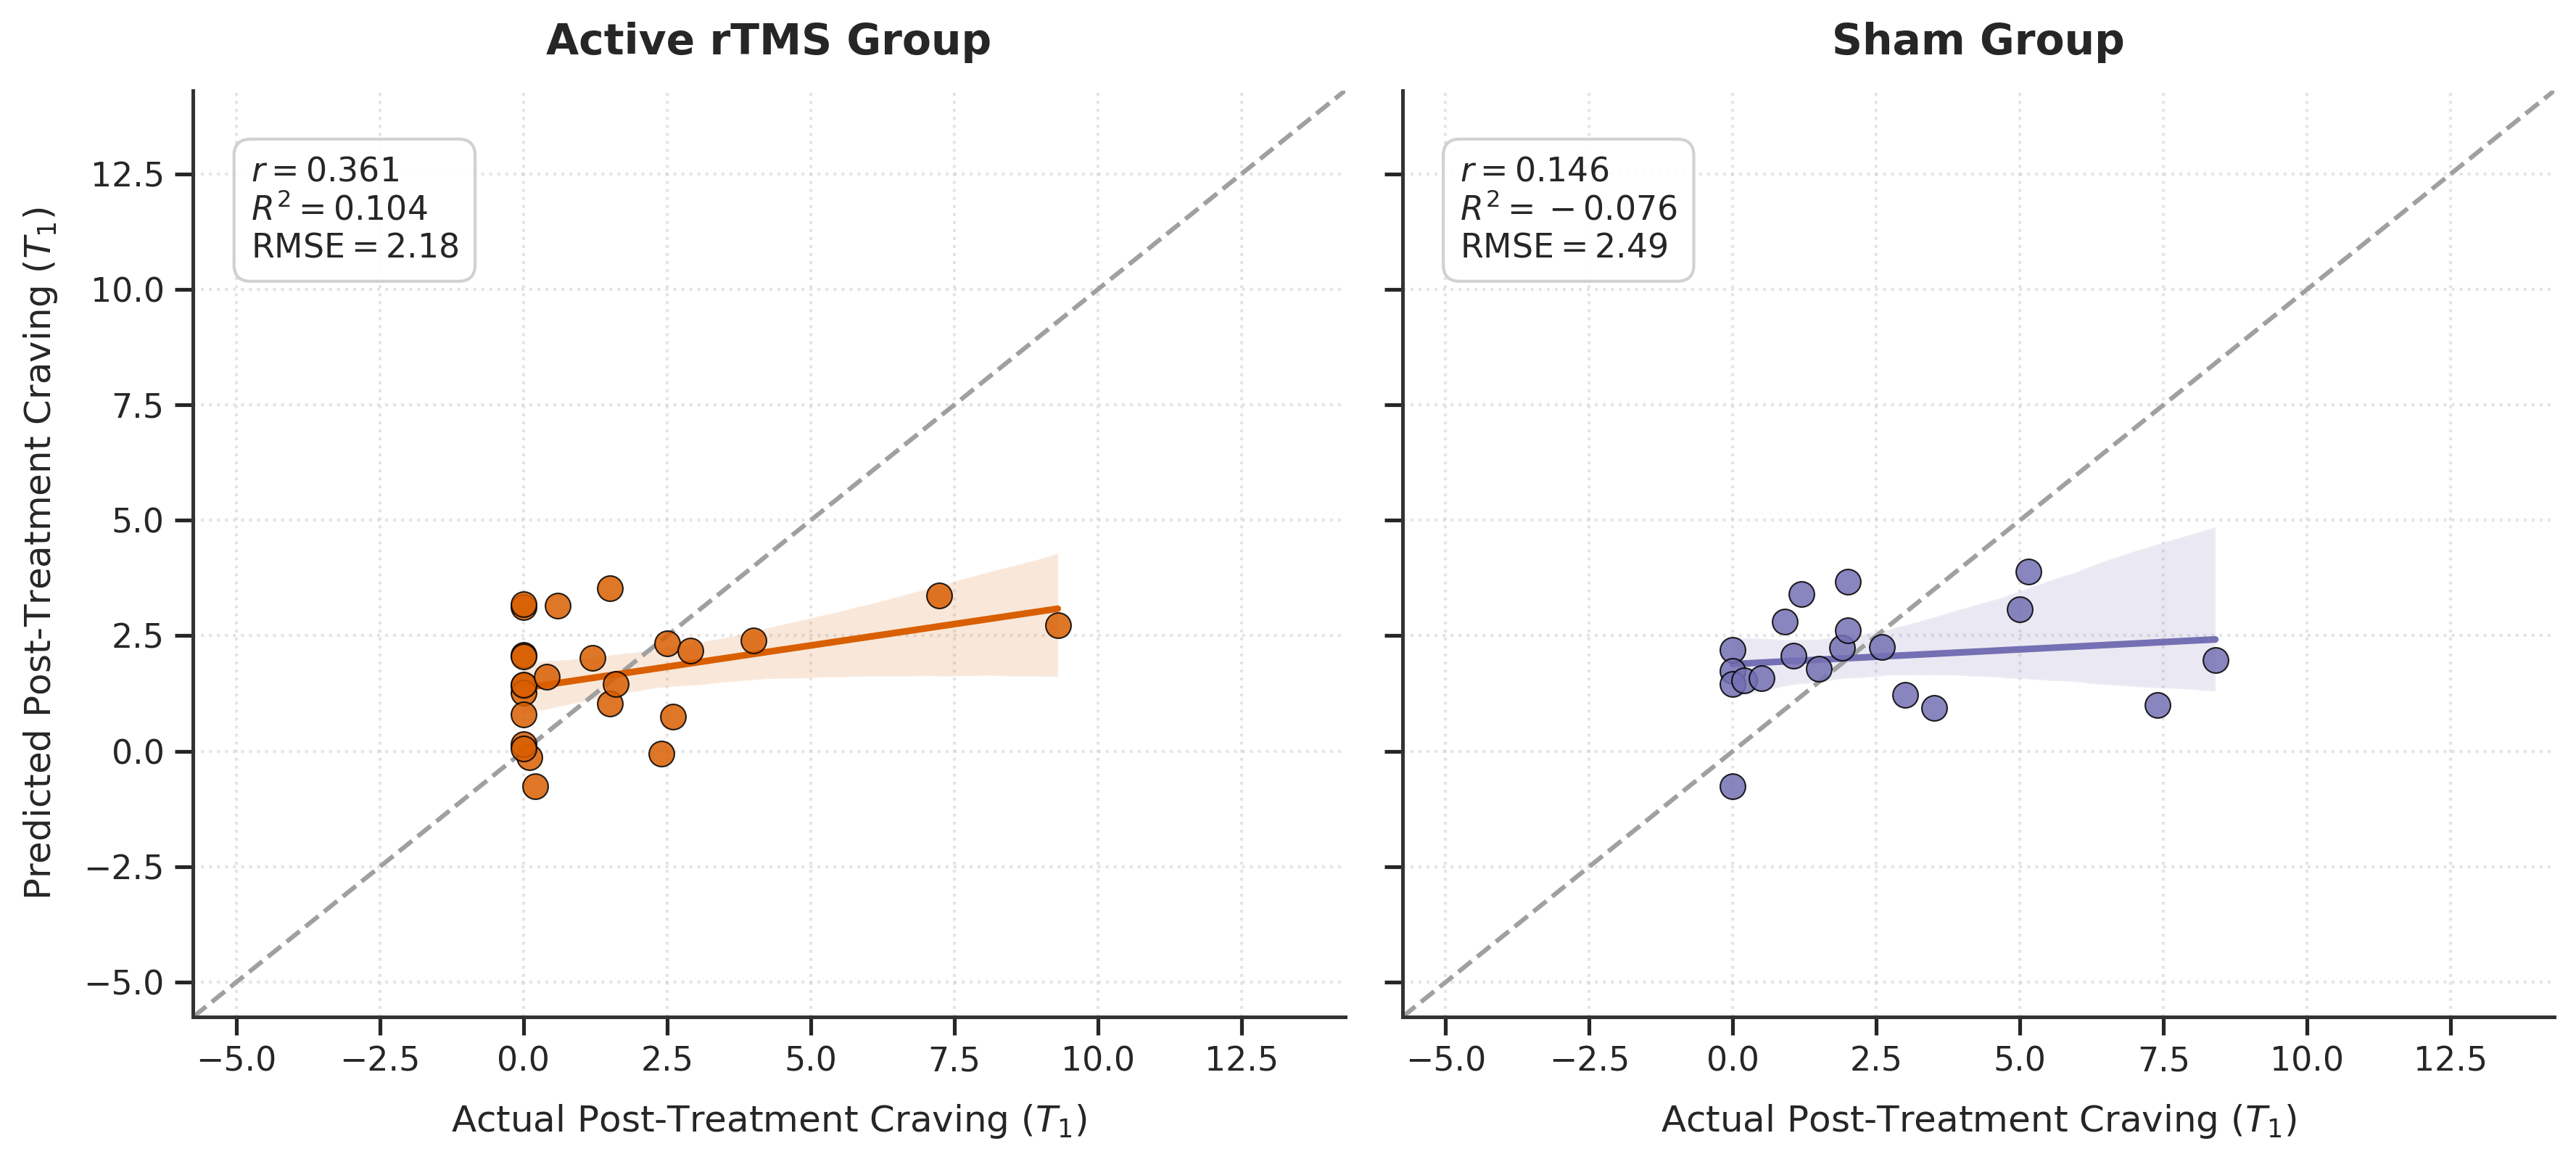

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean aesthetic style
sns.set_theme(style="ticks")
plt.rcParams['font.sans-serif'] = 'Helvetica'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 1.2

# 1. Map group codes (2 -> Active rTMS, 1 -> Sham)
plot_df = pd.DataFrame({
    'True_Craving': y_true,
    'Pred_Craving': y_pred,
    'Group': np.where(df['treatment_group'].values == 2, 'Active rTMS', 'Sham')
})

# 2. Setup figure canvas
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True, dpi=300)

palette = {'Active rTMS': '#D95F02', 'Sham': '#7570B3'} # Colorblind-safe palette

groups = ['Active rTMS', 'Sham']
metrics = [
    {'r': corr_active, 'r2': r2_active, 'rmse': rmse_active, 'mask': active_mask},
    {'r': corr_sham, 'r2': r2_sham, 'rmse': rmse_sham, 'mask': sham_mask}
]

# 3. Plot Active vs. Sham side-by-side
for i, grp in enumerate(groups):
    ax = axes[i]
    sub_df = plot_df[plot_df['Group'] == grp]
    m = metrics[i]
    color = palette[grp]
    
    # Draw 1:1 Identity Reference Line
    min_val = min(plot_df['True_Craving'].min(), plot_df['Pred_Craving'].min()) - 5
    max_val = max(plot_df['True_Craving'].max(), plot_df['Pred_Craving'].max()) + 5
    # ax.plot([min_val, max_val], [min_val, max_val], color='#A0A0A0', linestyle='--', linewidth=1.5, label='Identity Line (1:1)', zorder=1)
    ax.plot([min_val, max_val], [min_val, max_val], color='#A0A0A0', linestyle='--', linewidth=1.5, zorder=1)
    
    # Scatter points
    sns.scatterplot(
        data=sub_df, x='True_Craving', y='Pred_Craving', 
        color=color, s=70, alpha=0.85, edgecolor='black', linewidth=0.5, ax=ax, zorder=3
    )
    
    # Linear Regression Trendline with 95% CI
    sns.regplot(
        data=sub_df, x='True_Craving', y='Pred_Craving', 
        ax=ax, scatter=False, color=color, line_kws={'linewidth': 2.2}, ci=95
    )
    
    # Formatting & Statistics Box
    ax.set_title(f'{grp} Group', fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('Actual Post-Treatment Craving ($T_1$)', fontsize=12, labelpad=8)
    if i == 0:
        ax.set_ylabel('Predicted Post-Treatment Craving ($T_1$)', fontsize=12, labelpad=8)
    
    # Statistical performance text box
    stats_text = f"$r = {m['r']:.3f}$\n$R^2 = {m['r2']:.3f}$\n$\mathrm{{RMSE}} = {m['rmse']:.2f}$"
    ax.text(
        0.05, 0.82, stats_text, transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#CCCCCC')
    )
    
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.grid(True, linestyle=':', alpha=0.5)

sns.despine()
plt.tight_layout()

# Save figure
plt.savefig('SUDMEX_rTMS_Prediction_Active_vs_Sham.png', dpi=300, bbox_inches='tight')
plt.show()